
## Back to basics: Step 4.
## State model

This is our full state model:


$$s_{t+1} =s_t +v_t \cdot h+w_t$$

$$y=||r_{x,y} -{r_{x,y} }^{\left(i\right)} ||_2 \;+v_t$$


In matrix form:

 $ $ \begin{array}{l} s_{t+1} =\left\lbrack \begin{array}{cccc} 1 & 0 & h & 0\newline 0 & 1 & 0 & h\newline 0 & 0 & 1 & 0\newline 0 & 0 & 0 & 1 \end{array}\right\rbrack \left\lbrack \begin{array}{c} s\newline \delta s\newline v_s \newline v_{\delta s}  \end{array}\right\rbrack +\left\lbrack \begin{array}{cc} 0 & 0\newline 0 & \lambda \newline 1 & 0\newline 0 & 1 \end{array}\right\rbrack w_t \\
\\
w_t \sim \mathcal{N}\left(0,Q\right)\\
\lambda \in \left(0,1\right)
\end{array} $ $

Note to self: Depending on what we do with the model, there may be no noise term on the lateral position (the second entry in the state vector).


In [1]:
% Make sure to add Casadi to path and import it.
import casadi.*

trackPoints = readtable("track-coordinates.csv");

Set 'VariableNamingRule' to 'preserve' to use the original column headers as table variable names.

In [2]:
trackX = trackPoints.MidTrack_x_;
trackY = trackPoints.MidTrack_y_;
dx = diff(trackX);
dy = diff(trackY);
ds = sqrt(dx.^2 + dy.^2);
trackS = [0; cumsum(ds)];

% Tangent direction at each point (unit vector)
tx = dx ./ ds;
ty = dy ./ ds;
% Pad last element
tx = [tx; tx(end)];
ty = [ty; ty(end)];

% Normal direction (perpendicular to tangent)
nx_arr = -ty;
ny_arr =  tx;

% Setup.
fs = 100;
ht = 1/fs;

% State transition matrix.
A = [1 0 ht 0;
     0 1 0 ht;
     0 0 1 0;
     0 0 0 1];

% Noise variance for velocity, no position variance.
tanVelocityStd = 0.2;
latVelocityStd = 0.01;

Q = diag([tanVelocityStd, latVelocityStd].^2);

G = [0 0;
     0 0;
     1 0;
     0 1];

% Define where the beacons are on the track. These are triangular around
% the track. If we change the locations, this will provide worse estimates.
beaconLocations = [-100 20 180; -60 90 -10]';

% Do not do this. This is lazy and imprecise. I am doing it anyway.
nBeacons = length(beaconLocations);

X_interp  = casadi.interpolant('X',  'bspline', {trackS}, trackX');
Y_interp  = casadi.interpolant('Y',  'bspline', {trackS}, trackY');
NX_interp = casadi.interpolant('NX', 'bspline', {trackS}, nx_arr');
NY_interp = casadi.interpolant('NY', 'bspline', {trackS}, ny_arr');

% Symbolic state
x = MX.sym('x', 4);    % [s; y_lat; v_s; v_lat]
s = x(1);
y_lat = x(2);

% Centerline position
px_c = X_interp(s);
py_c = Y_interp(s);

% Normal direction (looked up, not differentiated)
nx = NX_interp(s);
ny = NY_interp(s);

% World position
px = px_c + y_lat * nx;
py = py_c + y_lat * ny;

% Range to each beacon, loop over the function for each beacon.
h = MX.zeros(nBeacons, 1);
for i = 1 : nBeacons
    h(i) = sqrt((px - beaconLocations(i, 1)) ^ 2 + (py - beaconLocations(i, 2)) ^ 2);
end

% Jacobian here.
jh = jacobian(h, x);
Jhx = Function('h', {x}, {h});
Jh = Function('Jh', {x}, {jh});

% Measurement noise.
mu = zeros(1, nBeacons);
r = 1.5;
R = r^2 * eye(nBeacons);

% Initialisation.
nSamples = 4500;
timeVector = (0 : nSamples) * ht;
stateVector = zeros(4, nSamples + 1);

% Need x and y co-ordinates.
measurementVector = zeros(nBeacons, nSamples);
currentPositionTrackX = zeros(1, nSamples);
currentPositionTrackY = zeros(1, nSamples);
estTrackX = zeros(1, nSamples);
estTrackY = zeros(1, nSamples);

% Kalman Filter estimates initialisiation.
x_mu = zeros(4, nSamples);
sigma_mu = cell(1, nSamples);

% State initialisation. If you want a mean value for velocity, just set the
% initial state to that value.
stateVector(:, 1) = [0 0 15 0]';

% Initial estimate. Offset needs to be small for convergence.
x_tu = [0; 0.5; 15; 1];
sigma_tu = diag([10, 5, 2, 1]);

for t = 1 : nSamples

    %% ----------------- STATE DYNAMICS SECTION --------------------
    % Noise for the velocity.
    processNoise = mvnrnd([0 0], Q)';

    % Note that there's no input terms here. They're in the script for
    % testing, but omitted because the model doesn't call for it.
    stateVector(:, t + 1) = A * stateVector(:, t) + G * processNoise;

    if stateVector(1, t + 1) >= trackS(end)
        nSamples = t;
        break;
    end

    % Position constraint.
    stateVector(2, t + 1) = min(max(stateVector(2, t + 1), -2), 2);

    % Velocity constraints.
    stateVector(3, t + 1) = min(max(stateVector(3, t + 1), 0), 25);
    stateVector(4, t + 1) = min(max(stateVector(4, t + 1), -0.55), 0.55);

    sPosition = stateVector(1, t);
    syPosition = stateVector(2, t);

    px_c = interp1(trackS, trackX, mod(sPosition, trackS(end)), 'pchip');
    py_c = interp1(trackS, trackY, mod(sPosition, trackS(end)), 'pchip');

    ds = 0.01;
    px_fwd = interp1(trackS, trackX, mod(sPosition + ds, trackS(end)), 'pchip');
    py_fwd = interp1(trackS, trackY, mod(sPosition + ds, trackS(end)), 'pchip');
    tx = (px_fwd - px_c) / ds;
    ty = (py_fwd - py_c) / ds;
    tn = sqrt(tx^2 + ty^2);
    nx = -ty / tn;
    ny =  tx / tn;

    currentPositionTrackX(:, t) = px_c + syPosition * nx;
    currentPositionTrackY(:, t) = py_c + syPosition * ny;

    trackPosition = [currentPositionTrackX(:, t) currentPositionTrackY(:, t)];

    % Euclidean distance of the current position to each beacon location.
    distFromBeacons = vecnorm(trackPosition - beaconLocations, 2, 2);

    % Actual noise model provided.
    measurementNoise = mvnrnd(mu, R)';

    % Final measurement.
    measurementVector(:, t) =  distFromBeacons + measurementNoise;

    %% -------------- KALMAN FILTER SECTION ------------------------
    % Jacobian steps to compute before Kalman Filter.
    h_x = full(Jhx(x_tu));
    C_lin = full(Jh(x_tu));

    % Keep a log of sigma and the estimated state. Measurement update.
    [sigma_mu{:, t}, x_mu(:, t)] = measurementUpdate(sigma_tu, x_tu, ...
        measurementVector(:, t), C_lin, R, h_x);



    % Time update step.
    [sigma_tu, x_tu] = timeUpdate(sigma_mu{:, t}, x_mu(:, t), A, Q, G);

    % Conversion step back into cartesian for the plots.
    s_est     = x_mu(1, t);
    y_lat_est = x_mu(2, t);

    px_c = interp1(trackS, trackX, mod(s_est, trackS(end)), 'pchip');
    py_c = interp1(trackS, trackY, mod(s_est, trackS(end)), 'pchip');

    ds = 0.01;
    px_fwd = interp1(trackS, trackX, mod(s_est + ds, trackS(end)), 'pchip');
    py_fwd = interp1(trackS, trackY, mod(s_est + ds, trackS(end)), 'pchip');
    tx = (px_fwd - px_c) / ds;
    ty = (py_fwd - py_c) / ds;
    tn = sqrt(tx^2 + ty^2);
    nx = -ty / tn;
    ny =  tx / tn;

    estTrackX(t) = px_c + y_lat_est * nx;
    estTrackY(t) = py_c + y_lat_est * ny;

end

% Set this up for later.
positionError = x_mu(1,:) - stateVector(1,1 : end - 1);
velocityError = x_mu(3,:) - stateVector(3,1 : end - 1);

## Plotting section

Learned some cool plotting techniques for animating the graphs. I'm pretty sure you can just remove the pause and it should be almost instant and bypass the animation for playing about with.


In [3]:
f = figure;
f.Position = [0 0 1500 1000];
tiledlayout(3, 3)

t1 = nexttile([2, 2]);
t2 = nexttile([1, 2]);
t3 = nexttile;
t4 = nexttile;
t5 = nexttile;

hold(t1, 'on')
hold(t2, 'on')
hold(t3, 'on')
hold(t4, 'on')
hold(t5, 'on')

beaconColours = {[1 0 0], [0 1 0], [1 1 1]};

xlabel(t1, 'X Position (m)')
ylabel(t1, 'Y Position (m)')

xlabel(t2, 'Time (s)')
ylabel(t2, 'Range (m)')
title(t2, 'Beacon ranges')

ylabel(t3, 'Arc Position (m)');
xlabel(t3, 'Time (s)')

ylabel(t4, 'Lateral position (m)')
xlabel(t4, 'Time (s)')

ylabel(t5, 'Error')
xlabel(t5, 'Time (s)')

% Beacons
for i = 1:nBeacons
    scatter(t1, beaconLocations(i,1), beaconLocations(i,2), ...
        100, 'sq', "yellow", 'filled', 'MarkerEdgeColor', [0 0 0], ...
        'LineWidth', 1.8);
    text(t1, beaconLocations(i, 1) - 10, beaconLocations(i, 2) - 10, ...
        "Beacon " + string(i))
end

%% --- Plot static elements (only once) ---
plot(t1, trackPoints.OuterTrack_x_, trackPoints.OuterTrack_y_, 'k', ...
    'LineWidth', 2, 'DisplayName', 'Outer Track')
plot(t1, trackPoints.InnerTrack_x_, trackPoints.InnerTrack_y_, 'k', ...
    'LineWidth', 2, 'DisplayName', 'Inner Track')
plot(t1, trackPoints.MidTrack_x_, trackPoints.MidTrack_y_, 'k--', ...
    'LineWidth', 1.5, 'DisplayName', 'Middle Track')
xlim(t1, [-150 200])
ylim(t1, [-100 100])

%% --- Pre-create animated objects ---

% Trajectory
h_traj = plot(t1, NaN, NaN, 'r', 'LineWidth', 1.8, ...
    'DisplayName', 'Position');
arcTrajectory = plot(t1, NaN, NaN, '--b', 'LineWidth', 1.4, ...
    'DisplayName', 'Estimated Position');

% Tile 3
sTrajectory = plot(t3, NaN, NaN, 'r', 'LineWidth', 1.4, ...
    'DisplayName', 'True position');
sEstTrajectory = plot(t3, NaN, NaN, 'b--', 'LineWidth', 1.2, ...
    'DisplayName', 'Estimated position');

% Tile 4
syTrajectory = plot(t4, NaN, NaN, 'r', 'LineWidth', 1.4, ...
    'DisplayName', 'True lateral position');
syEstTrajectory = plot(t4, NaN, NaN, 'b--', 'LineWidth', 1.4, ...
    'DisplayName', 'Estimated lateral position');

% Tile 5
errorSTrajectory = plot(t5, NaN, NaN, 'r', 'LineWidth', 1.4, ...
    'DisplayName', 'Position error');
errorVTrajectory = plot(t5, NaN, NaN, 'b--', 'LineWidth', 1.2, ...
    'DisplayName', 'Velocity error');

% Beacon range lines
h_range = gobjects(1, nBeacons);

for i = 1:nBeacons
    h_range(i) = plot(t2, NaN, NaN, ...
        'Color', [0 0 0]);
end

legend(t1, 'show', {'', '', '', 'Track boundaries', '', ...
    'Centre line', 'True position', 'Estimated position'})
legend(t3, 'show', 'Location', 'southeast')
legend(t4, 'show', 'Location', 'northeast')
legend(t5, 'show')

%% --- Animation loop ---

for i = 1 : 20 : nSamples

    % Update trajectory
    set(h_traj, ...
        'XData', currentPositionTrackX(1:i), ...
        'YData', currentPositionTrackY(1:i));
    set(arcTrajectory, ...
        'XData', estTrackX(1 : i), ...
        'YData', estTrackY(1 : i));

    % Update beacon ranges
    for b = 1:nBeacons
        set(h_range(b), ...
            'XData', timeVector(1:i), ...
            'YData', measurementVector(b,1:i));
    end

    set(sTrajectory, ...
        'XData', timeVector(1:i), ...
        'YData', stateVector(1, 1:i));
    set(sEstTrajectory, ...
        'XData', timeVector(1:i), ...
        'YData', x_mu(1, 1:i));

    set(syTrajectory, ...
        'XData', timeVector(1:i), ...
        'YData', stateVector(2, 1:i));
    set(syEstTrajectory, ...
        'XData', timeVector(1:i), ...
        'YData', x_mu(2, 1:i));

    set(errorSTrajectory, ...
        'XData', timeVector(1:i), ...
        'YData', positionError(1, 1:i));
    set(errorVTrajectory, ...
        'XData', timeVector(1:i), ...
        'YData', velocityError(1, 1:i));

    drawnow limitrate
    pause(0.0001)
end


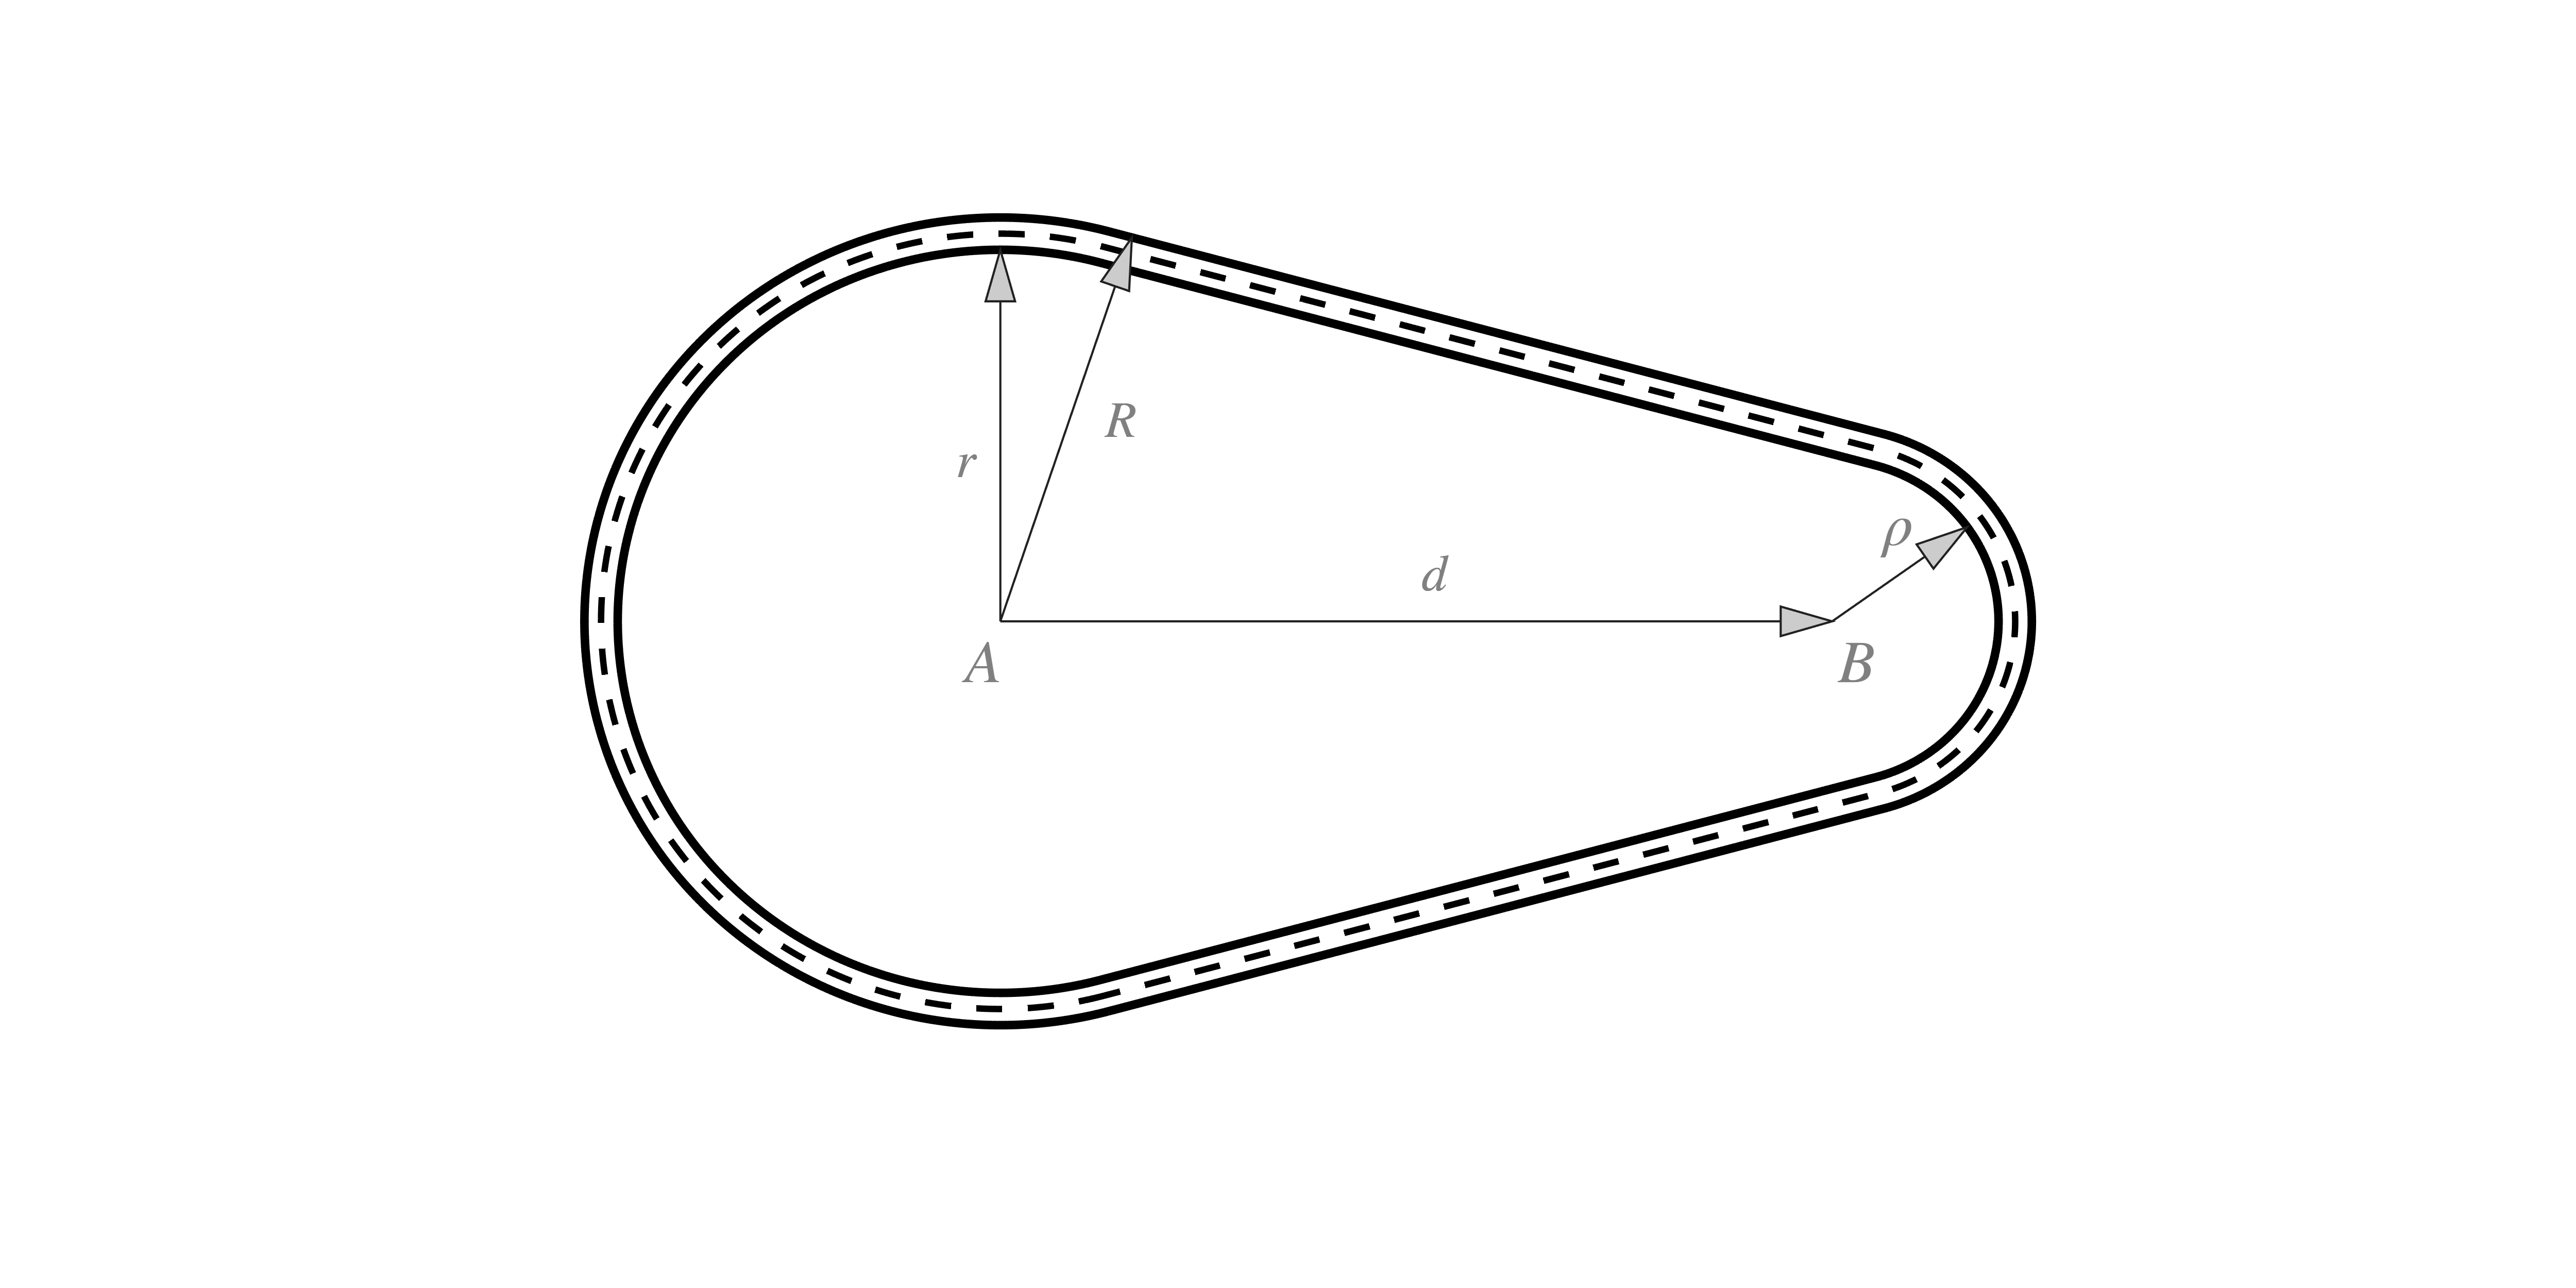

In [4]:

%  Delete this later.
f = figure;
f.Position = [0 0 800 400];
hold on
plot(trackPoints.OuterTrack_x_, trackPoints.OuterTrack_y_, 'k', ...
    'LineWidth', 2, 'DisplayName', 'Outer Track')
plot(trackPoints.InnerTrack_x_, trackPoints.InnerTrack_y_, 'k', ...
    'LineWidth', 2, 'DisplayName', 'Inner Track')
plot(trackPoints.MidTrack_x_, trackPoints.MidTrack_y_, 'k--', ...
    'LineWidth', 1.5, 'DisplayName', 'Middle Track')
ylim([-65 65])
xlim([-80 160])

arrow([0, 0], [0, 46], 'FaceColor', [0.8 0.8 0.8])
arrow([0, 0], [15.8113, 47.5235], 'FaceColor', [0.8 0.8 0.8])
arrow([0, 0], [100, 0], 'FaceColor', [0.8 0.8 0.8])
arrow([100, 0], [116.241, 11.672], 'FaceColor', [0.8 0.8 0.8])

text(-5, -5, '{\it A}', 'Interpreter', 'latex', 'Color', [0.5 0.5 0.5], 'FontSize', 14)
text(-6, 20, '{\it r}', 'Interpreter', 'latex', 'Color', [0.5 0.5 0.5], 'FontSize', 12)
text(12, 25, '{\it R}', 'Interpreter', 'latex', 'Color', [0.5 0.5 0.5], 'FontSize', 12)
text(50, 6, '{\it d}', 'Interpreter', 'latex', 'Color', [0.5 0.5 0.5], 'FontSize', 12)
text(100, -5, '{\it B}', 'Interpreter', 'latex', 'Color', [0.5 0.5 0.5], 'FontSize', 14)
text(105, 12, '$\rho$', 'Interpreter', 'latex', 'Color', [0.5 0.5 0.5], 'FontSize', 14)
axis off

savefig('Control/estimation-theory-car-tracker/report/figures/track-geometry.fig')
exportgraphics(f, 'Control/estimation-theory-car-tracker/report/figures/track-geometry.png', 'Resolution', 600)

In [5]:

function [sigma, x] = measurementUpdate(sigma, x, y, C, R, h_x)
    z = C * sigma * C' + R;
    x = x + sigma * C' * linsolve(z, y - h_x);
    sigma = sigma - sigma * C' * linsolve(z, C * sigma);
end

function [sigma, x] = timeUpdate(sigma, x, A, Q, G)
    x = A * x;
    sigma = A * sigma * A' + G * Q *G';
end
